In [12]:
import os
from  typing_extensions import TypedDict


from dotenv import load_dotenv
from langchain_groq import  ChatGroq
from langchain_core.documents import  Document
from langchain_text_splitters import  RecursiveCharacterTextSplitter
from langchain_huggingface import  HuggingFaceEmbeddings
from langchain_astradb import AstraDBVectorStore
from langchain_community.document_loaders import PyPDFLoader

from langgraph.graph import  StateGraph,END,START
from langgraph.prebuilt import ToolNode,tools_condition
from langgraph.graph.message import  MessagesState
from langchain_core.tools import  tool
from pydantic import BaseModel

from langchain_core.messages import  HumanMessage,SystemMessage
from langgraph.types import  Command ,interrupt
from langgraph.checkpoint.memory import  InMemorySaver


In [2]:


load_dotenv()
# Set your Astra DB credentials
os.environ["ASTRA_DB_API_ENDPOINT"] = os.getenv("Astra_DB_API_Endpoint")
os.environ["ASTRA_DB_APPLICATION_TOKEN"] = os.getenv("Astra_DB_Token")
load_dotenv()

os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["LANGCHAIN_API_KEY"] = os.getenv("LANGSMITH_API_KEY")
os.environ["LANGCHAIN_PROJECT"] = os.getenv("LANGSMITH_PROJECT")

os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

llm = ChatGroq(model="openai/gpt-oss-120b")


In [3]:
emb=HuggingFaceEmbeddings(model_name="BAAI/bge-small-en-v1.5")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

In [4]:



vectore_store=AstraDBVectorStore(

embedding=emb,
collection_name="GENRAL_TASKS",

api_endpoint= os.getenv("Astra_DB_API_Endpoint"),
token=os.getenv("Astra_DB_Token")
)

In [7]:
'''
sample_texts = [
    "Astra DB is a serverless vector database built on Apache Cassandra.",
    "LangGraph allows you to build stateful, multi-actor applications with LLMs.",
    "RAG systems combine retrieval of private data with generative AI models to prevent hallucinations."
]
docs=[Document(page_content=text,metadata={"source":"notebook_test"}) for text in sample_texts]
'''
LOADER=PyPDFLoader("stilaite.pdf")
pdf_pages=LOADER.load()


text_spliter=RecursiveCharacterTextSplitter(chunk_size=1000,chunk_overlap=200)
splits_docs=text_spliter.split_documents(pdf_pages)

splits_docs


[Document(metadata={'producer': 'pikepdf 8.15.1', 'creator': 'arXiv GenPDF (tex2pdf:0d14211)', 'creationdate': '', 'author': 'Florian Cheyssial; Laurent M. Mugnier; Cyril Petit', 'doi': 'https://doi.org/10.48550/arXiv.2609.17023', 'license': 'http://arxiv.org/licenses/nonexclusive-distrib/1.0/', 'ptex.fullbanner': 'This is pdfTeX, Version 3.141592653-2.6-1.40.28 (TeX Live 2025) kpathsea version 6.4.1', 'title': 'Optimal exposure time for satellite imaging? A trade-off between residual tip-tilt and registration accuracy', 'trapped': '/False', 'arxivid': 'https://arxiv.org/abs/2609.17023v1', 'source': 'stilaite.pdf', 'total_pages': 7, 'page': 0, 'page_label': '1'}, page_content='To be published inAdaptive Optics Systems X, volume 14150, SPIE Astronomical Telescopes +\nInstrumentation, Copenhagen, 2026.\nOptimal exposure time for satellite imaging? A trade-off\nbetween residual tip-tilt and registration accuracy\nFlorian Cheyssiala, Laurent M. Mugnier a, and Cyril Petit a\naDOTA, ONERA, U

In [9]:
print(f"Loaded {len(pdf_pages)} pages from the PDF.")
print(f"Split the PDF into {len(splits_docs)} chunks.")


Loaded 7 pages from the PDF.
Split the PDF into 36 chunks.


In [10]:
insert_ids=vectore_store.add_documents(splits_docs)

In [13]:
print(f"Inserted {len(insert_ids)} document chunks into Astra DB.")

Inserted 3 document chunks into Astra DB.


In [12]:
query = "TRADE-OFF BETWEEN INTEGRATED JITTER & REGISTRATION ERROR"


res=vectore_store.similarity_search_with_score(query,k=3)
for doc ,score in res:
    print(f"score :{score} the doc:{doc}")


    


score :0.89365655 the doc:page_content='certain threshold (here around 10 ms), all the jitter statistic is integrated. Past this threshold, there is no interest
in making registration. Compared to a long pose, jitter effects are reduced by≈66% at the optimal exposure
time.
To make a comparison with the CRLB, we calculate empirically the standard deviation of the registration
error,σ reg, for two cases. In the first case, the reference imagegis known, as it is supposed in the calculation of
5 of 7' metadata={'producer': 'pikepdf 8.15.1', 'creator': 'arXiv GenPDF (tex2pdf:0d14211)', 'creationdate': '', 'author': 'Florian Cheyssial; Laurent M. Mugnier; Cyril Petit', 'doi': 'https://doi.org/10.48550/arXiv.2609.17023', 'license': 'http://arxiv.org/licenses/nonexclusive-distrib/1.0/', 'ptex.fullbanner': 'This is pdfTeX, Version 3.141592653-2.6-1.40.28 (TeX Live 2025) kpathsea version 6.4.1', 'title': 'Optimal exposure time for satellite imaging? A trade-off between residual tip-tilt and regi

In [5]:
retriver=vectore_store.as_retriever(search_kwargs={"k":2})







In [ ]:
ress=retriver.invoke("who was the author? ")
for  i , doc in enumerate(ress):
    res=llm.invoke(doc.page_content)
    print(res.content)

It looks like you’ve pasted a short list of references (items 5‑7) that relate to pyramid wave‑front sensors and their optical gains. How can I help you with them?  

Some common requests include:

* **Formatting the citations** in a specific style (APA, IEEE, Chicago, etc.).  
* **Creating a complete bibliography** (adding missing details such as DOIs, page ranges, or publisher information).  
* **Summarizing the key findings** of each paper.  
* **Explaining how to incorporate the “pyramid optical gains”** from the Fetick et al. (2023) conference paper into an analytical model.  
* **Generating in‑text citations** for a manuscript you’re writing.  

Just let me know which of the above (or anything else) you need, and I’ll take it from there!
Below is a compact yet complete walkthrough of the material you quoted, together with practical pointers on how to turn the theory into an implementable algorithm. I’ve split the answer into three logical blocks:

1. **What “tip‑tilt PSD” means a

In [6]:
# SCHEMA OF THE 


class AgentState(MessagesState):
    query:str
    context:str
    draft:str
    feedback:str
    final:str

In [25]:
# nodes 

def retriver_node(state:AgentState):
    print("RETRIVING FROM DATA BASE -----")
    docs= retriver.invoke (state["query"]) 
    formatecontex= "\n\n".join(doc.page_content for doc in docs)
    return formatecontex




def draft_node(state:AgentState):
    print("drafting----")
    system_prompt = (
        "You are a helpful assistant. Answer the user's query using ONLY "
        "the provided context. If you don't know the answer based on the context, say so.\n\n"
        f"Context: {state['context']}"
    )
    messages=[
        SystemMessage(content=system_prompt),
        HumanMessage(content=state["query"])
    ]   
    resp=llm.invoke(messages)
    
    return{"draft":resp.content} 


def humman_revivew_node(state:AgentState):
    print ("human reviewing------")
    human_input = interrupt(
        f"DRAFT GENERATED:\n{state['draft']}\n\n"
        "Provide feedback to revise, or type 'Approve' to proceed."
    )
    return{ "feedback":human_input}


def finalize_node(state:AgentState):
    print("--final ans--")
    if state["feedback"].strip().lower()=="approve":
        return {"final_answer":state["draft"]}
    revision_prompt = (
        f"Revise this draft based on the human's feedback.\n\n"
        f"Original Draft: {state['draft']}\n"
        f"Human Feedback: {state['feedback']}"
    )


    resp=llm.invoke([HumanMessage(content=revision_prompt)])
    return {"final_ansewer":resp.content}



    


In [36]:
# graphbuilding

# graphbuilding
graph=StateGraph(AgentState) # <--- CHANGE MessagesState TO AgentState
graph.add_node(  "node_ret",    retriver_node     )
graph.add_node( "drafting",     draft_node       )
graph.add_node(  "human_review",humman_revivew_node)
graph.add_node(   "final_ans",  finalize_node     )
# ... (rest of the cell)



In [37]:
graph.add_edge(START, "node_ret")
graph.add_edge("node_ret", "drafting")
graph.add_edge("drafting", "human_review")
graph.add_edge("human_review", "final_ans")
graph.add_edge("final_ans", END)

In [38]:
memory=InMemorySaver()
app=graph.compile(checkpointer=memory)

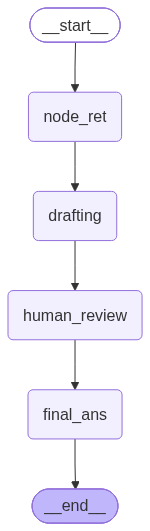

In [22]:
app

In [39]:
thread = {"configurable": {"thread_id": "pdf_rag_run_1"}}
initial_input = {"query": "What are the main conclusions in the document?"}

for event in app.stream(initial_input, thread, stream_mode="updates"):
    print(event)

RETRIVING FROM DATA BASE -----


InvalidUpdateError: Expected dict, got ence], (Sept. 2020).
[7] Fetick, R., Chambouleyron, V., and Taissir Heritier, C., “Including the pyramid optical gains into analytical
models,” 9 pages, Proceedings of AO4ELT7 conference 2023 - Editors: Thierry Fusco and Benoit Neichel
(2023).
7 of 7

then be performed on the registered image to correct for the remaining aberrations. The quality of the registered
Send correspondence to F.C. Email = firstname.lastname@onera.fr
1 of 7
arXiv:2609.17023v1  [astro-ph.IM]  15 Sep 2026
For troubleshooting, visit: https://docs.langchain.com/oss/python/langgraph/errors/INVALID_GRAPH_NODE_RETURN_VALUE

In [40]:
# Cell 2: Resume the run
from langgraph.types import Command

# Change this string to "Approve" to accept, or write feedback to trigger a revision
human_feedback = "Approve"

for event in app.stream(Command(resume=human_feedback), thread, stream_mode="updates"):
    print(event)

# Print the final answer stored in the state
final_state = app.get_state(thread)
print("\n--- FINAL ANSWER ---")
print(final_state.values.get("final_answer"))

RETRIVING FROM DATA BASE -----


InvalidUpdateError: Expected dict, got ence], (Sept. 2020).
[7] Fetick, R., Chambouleyron, V., and Taissir Heritier, C., “Including the pyramid optical gains into analytical
models,” 9 pages, Proceedings of AO4ELT7 conference 2023 - Editors: Thierry Fusco and Benoit Neichel
(2023).
7 of 7

then be performed on the registered image to correct for the remaining aberrations. The quality of the registered
Send correspondence to F.C. Email = firstname.lastname@onera.fr
1 of 7
arXiv:2609.17023v1  [astro-ph.IM]  15 Sep 2026
For troubleshooting, visit: https://docs.langchain.com/oss/python/langgraph/errors/INVALID_GRAPH_NODE_RETURN_VALUE